<a href="https://colab.research.google.com/github/keermani006/MACHINE-LEARNING/blob/main/LAB-2/ML_LAB_2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediction of Disease Susceptibility Using Logistic Regression

## Aim of the Project
The objective of the project is to develop a model of prediction using Logistic Regression that helps predict the susceptibility of a person to the particular disease.

## Description of Dataset
The dataset used includes data on the individuals, their disease condition and some other variables which might influence the disease status.

## Target Variable
**Disease status**
*   'Diseased' - denotes the occurrence of the disease.
*   'Not Diseased' - denotes the absence of the disease.

## Predictors
*   **Age** - Age of the individual.
*   **Gender** - Gender of the individual.
*   **Smoker status** - Smoker/Non-smoker.

## Machine Learning Model Used
**Logistic Regression**: A classification machine learning algorithm that can be used for the particular problem.

In [ ]:
# ============================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# ============================================
# 2. LOAD THE DATASET
# ============================================

file_path = "/content/numiqo.xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="Data"
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
# ============================================
# 3. DISPLAY THE DATASET
# ============================================

df

,Disease,Age,Gender,Smoker status
0,diseased,43,Male,Smoker
1,not diseased,18,Male,Smoker
2,diseased,22,Female,Non-smoker
3,diseased,25,Male,Non-smoker
4,not diseased,45,Female,Smoker
5,not diseased,12,Male,Non-smoker
6,diseased,23,Male,Smoker
7,diseased,33,Male,Smoker
8,not diseased,27,Male,Non-smoker
9,not diseased,27,Female,Non-smoker


In [ ]:
# ============================================
# 4. CHECK DATASET DIMENSIONS
# ============================================

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 36
Number of columns: 4


In [ ]:
# ============================================
# 5. DISPLAY COLUMN NAMES
# ============================================

print("Column names:")
print(df.columns.tolist())


Column names:
['Disease', 'Age', 'Gender', 'Smoker status']


In [ ]:
# ============================================
# 6. CHECK DATASET INFORMATION
# ============================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Disease        36 non-null     object
 1   Age            36 non-null     int64 
 2   Gender         36 non-null     object
 3   Smoker status  36 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.3+ KB


In [ ]:
# ============================================
# 7. STATISTICAL SUMMARY
# ============================================

df.describe(include="all")

,Disease,Age,Gender,Smoker status
count,36,36.000000,36,36
unique,2,NaN,2,2
top,diseased,NaN,Male,Smoker
freq,20,NaN,23,20
mean,NaN,40.194444,NaN,NaN
std,NaN,18.170336,NaN,NaN
min,NaN,12.000000,NaN,NaN
25%,NaN,27.000000,NaN,NaN
50%,NaN,34.000000,NaN,NaN
75%,NaN,45.750000,NaN,NaN


In [ ]:
# ============================================
# 8. CHECK FOR MISSING VALUES
# ============================================

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Disease          0
Age              0
Gender           0
Smoker status    0
dtype: int64


In [ ]:
# ============================================
# 9. CHECK DISEASE VALUES
# ============================================

print("Unique disease values:")
print(df["Disease"].unique())

print("\nDisease value counts:")
print(df["Disease"].value_counts())

Unique disease values:
['diseased' 'not diseased']

Disease value counts:
Disease
diseased        20
not diseased    16
Name: count, dtype: int64


In [ ]:
# ============================================
# 10. CHECK GENDER VALUES
# ============================================

print("Unique gender values:")
print(df["Gender"].unique())

print("\nGender value counts:")
print(df["Gender"].value_counts())

Unique gender values:
['Male' 'Female']

Gender value counts:
Gender
Male      23
Female    13
Name: count, dtype: int64


In [ ]:
# ============================================
# 11. CHECK SMOKER STATUS VALUES
# ============================================

print("Unique smoker status values:")
print(df["Smoker status"].unique())

print("\nSmoker status value counts:")
print(df["Smoker status"].value_counts())

Unique smoker status values:
['Smoker' 'Non-smoker']

Smoker status value counts:
Smoker status
Smoker        20
Non-smoker    16
Name: count, dtype: int64


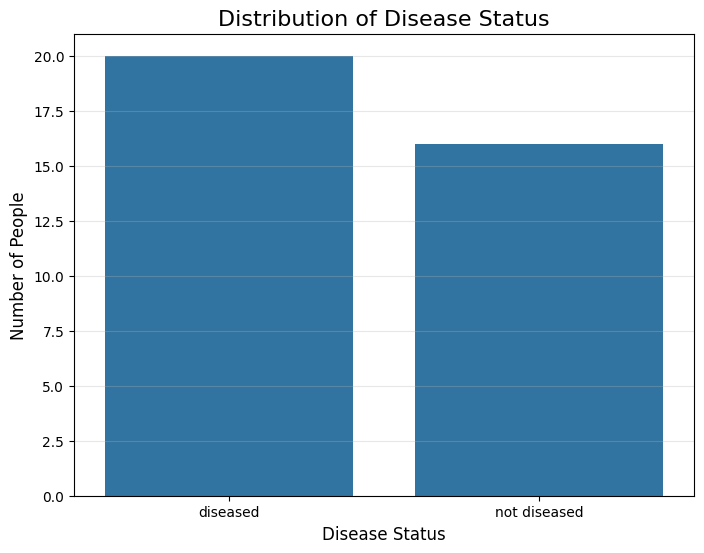

In [ ]:
# ============================================
# 12. DISEASE DISTRIBUTION
# ============================================

plt.figure(figsize=(8, 6))

sns.countplot(
    data=df,
    x="Disease"
)

plt.xlabel(
    "Disease Status",
    fontsize=12
)

plt.ylabel(
    "Number of People",
    fontsize=12
)

plt.title(
    "Distribution of Disease Status",
    fontsize=16
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

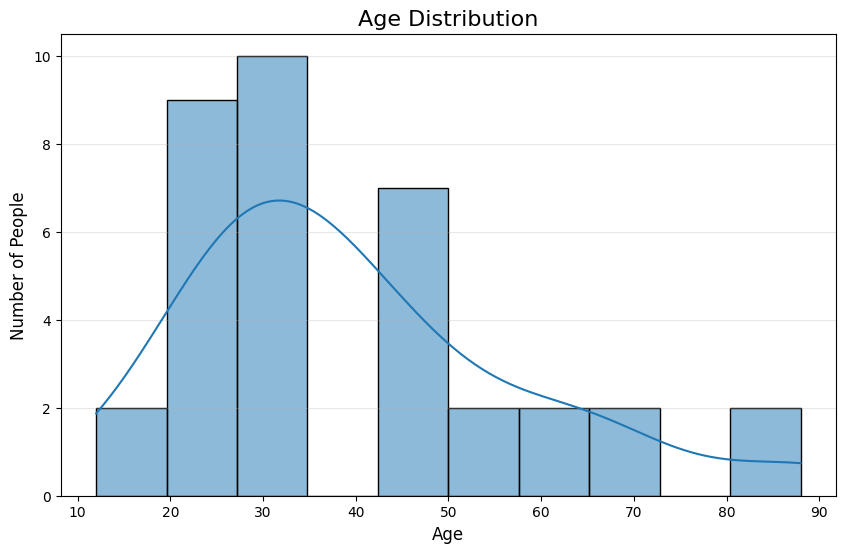

In [ ]:
# ============================================
# 13. AGE DISTRIBUTION
# ============================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Age",
    bins=10,
    kde=True
)

plt.xlabel(
    "Age",
    fontsize=12
)

plt.ylabel(
    "Number of People",
    fontsize=12
)

plt.title(
    "Age Distribution",
    fontsize=16
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


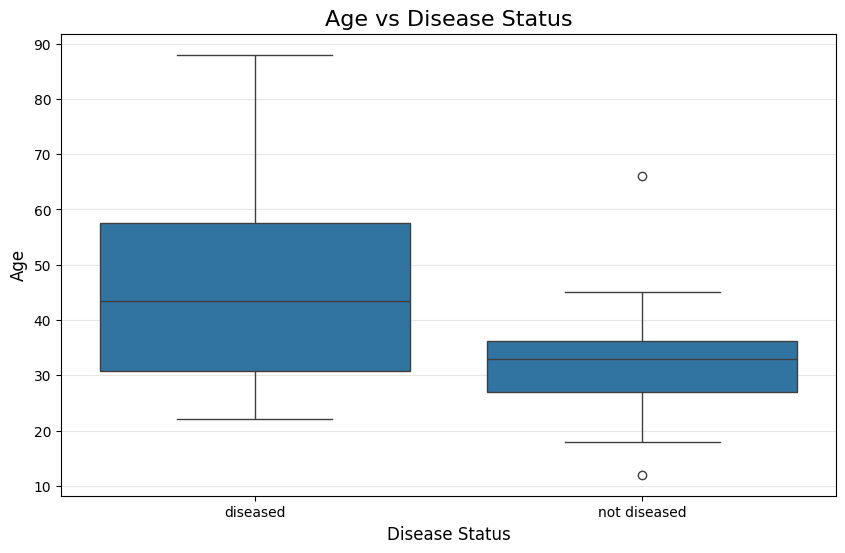

In [ ]:
# ============================================
# 14. AGE VS DISEASE
# ============================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Disease",
    y="Age"
)

plt.xlabel(
    "Disease Status",
    fontsize=12
)

plt.ylabel(
    "Age",
    fontsize=12
)

plt.title(
    "Age vs Disease Status",
    fontsize=16
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

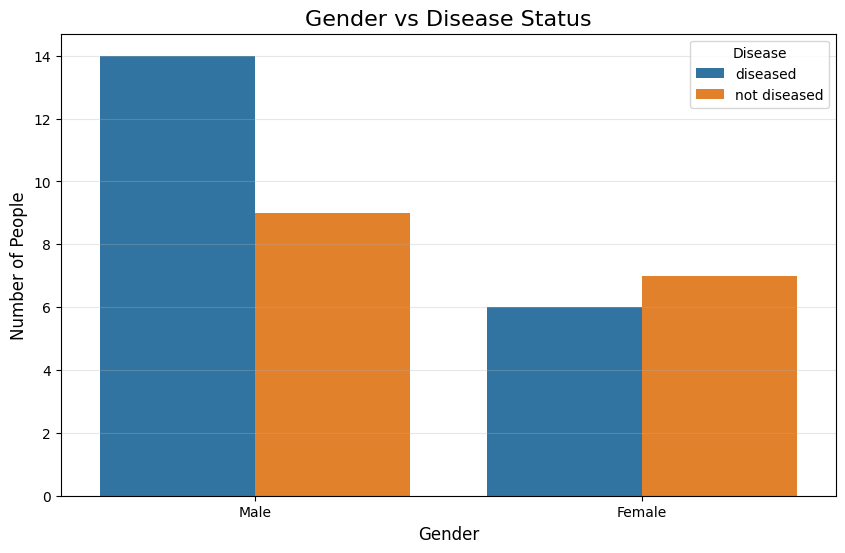

In [ ]:
# ============================================
# 15. GENDER VS DISEASE
# ============================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Gender",
    hue="Disease"
)

plt.xlabel(
    "Gender",
    fontsize=12
)

plt.ylabel(
    "Number of People",
    fontsize=12
)

plt.title(
    "Gender vs Disease Status",
    fontsize=16
)

plt.legend(
    title="Disease"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

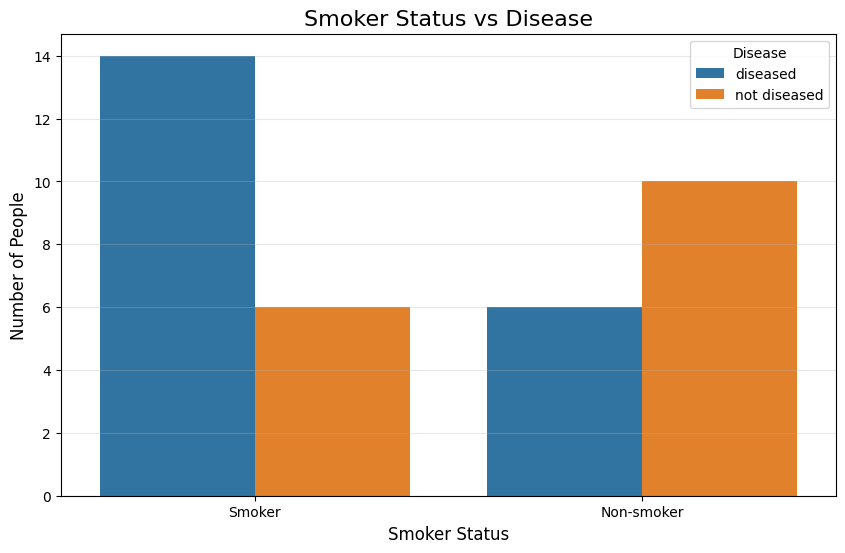

In [ ]:
# ============================================
# 16. SMOKER STATUS VS DISEASE
# ============================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Smoker status",
    hue="Disease"
)

plt.xlabel(
    "Smoker Status",
    fontsize=12
)

plt.ylabel(
    "Number of People",
    fontsize=12
)

plt.title(
    "Smoker Status vs Disease",
    fontsize=16
)

plt.legend(
    title="Disease"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

In [ ]:
# ============================================
# 17. ENCODE CATEGORICAL VARIABLES
# ============================================

df_encoded = df.copy()

df_encoded["Disease"] = df_encoded["Disease"].map({
    "not diseased": 0,
    "diseased": 1
})

df_encoded["Gender"] = df_encoded["Gender"].map({
    "Female": 0,
    "Male": 1
})

df_encoded["Smoker status"] = df_encoded["Smoker status"].map({
    "Non-smoker": 0,
    "Smoker": 1
})

df_encoded.head()

,Disease,Age,Gender,Smoker status
0,1,43,1,1
1,0,18,1,1
2,1,22,0,0
3,1,25,1,0
4,0,45,0,1


In [ ]:
# ============================================
# 18. CHECK ENCODED DATASET
# ============================================

df_encoded

,Disease,Age,Gender,Smoker status
0,1,43,1,1
1,0,18,1,1
2,1,22,0,0
3,1,25,1,0
4,0,45,0,1
5,0,12,1,0
6,1,23,1,1
7,1,33,1,1
8,0,27,1,0
9,0,27,0,0


In [ ]:
# ============================================
# 19. DEFINE FEATURES AND TARGET
# ============================================

X = df_encoded[
    ["Age", "Gender", "Smoker status"]
]

y = df_encoded["Disease"]

print("Independent Variables:")
print(X.head())

print("\nDependent Variable:")
print(y.head())

Independent Variables:
   Age  Gender  Smoker status
0   43       1              1
1   18       1              1
2   22       0              0
3   25       1              0
4   45       0              1

Dependent Variable:
0    1
1    0
2    1
3    1
4    0
Name: Disease, dtype: int64


In [ ]:
# ============================================
# 20. SPLIT THE DATASET
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 28
Testing samples: 8


In [ ]:
# ============================================
# 21. CREATE LOGISTIC REGRESSION MODEL
# ============================================

model = LogisticRegression()

model.fit(
    X_train,
    y_train
)

print(
    "Logistic Regression model trained successfully."
)

Logistic Regression model trained successfully.


In [ ]:
# ============================================
# 22. DISPLAY MODEL COEFFICIENTS
# ============================================

print("Intercept:", model.intercept_[0])

print("\nCoefficients:")

for feature, coefficient in zip(
    X.columns,
    model.coef_[0]
):
    print(
        feature,
        ":",
        coefficient
    )

Intercept: -2.06417323182584

Coefficients:
Age : 0.036583451284112105
Gender : 0.7769856889243318
Smoker status : 0.7752498372450469


In [ ]:
# ============================================
# 23. MAKE DISEASE PREDICTIONS
# ============================================

y_pred = model.predict(X_test)

print("Predicted disease values:")
print(y_pred)

Predicted disease values:
[1 0 0 0 0 1 0 1]


In [ ]:
# ============================================
# 24. PREDICT DISEASE PROBABILITIES
# ============================================

y_probability = model.predict_proba(
    X_test
)[:, 1]

print(
    "Predicted probability of disease:"
)

print(y_probability)

Predicted probability of disease:
[0.87348788 0.22108799 0.48916415 0.42569576 0.47047116 0.61469294
 0.42569576 0.86599321]


In [ ]:
# ============================================
# 25. COMPARE ACTUAL AND PREDICTED VALUES
# ============================================

comparison = pd.DataFrame({
    "Actual Disease": y_test.values,
    "Predicted Disease": y_pred,
    "Disease Probability": y_probability
})

comparison

,Actual Disease,Predicted Disease,Disease Probability
0,1,1,0.873488
1,1,0,0.221088
2,0,0,0.489164
3,0,0,0.425696
4,0,0,0.470471
5,1,1,0.614693
6,0,0,0.425696
7,1,1,0.865993


In [ ]:
# ============================================
# 26. CALCULATE MODEL ACCURACY
# ============================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

Accuracy: 87.5 %


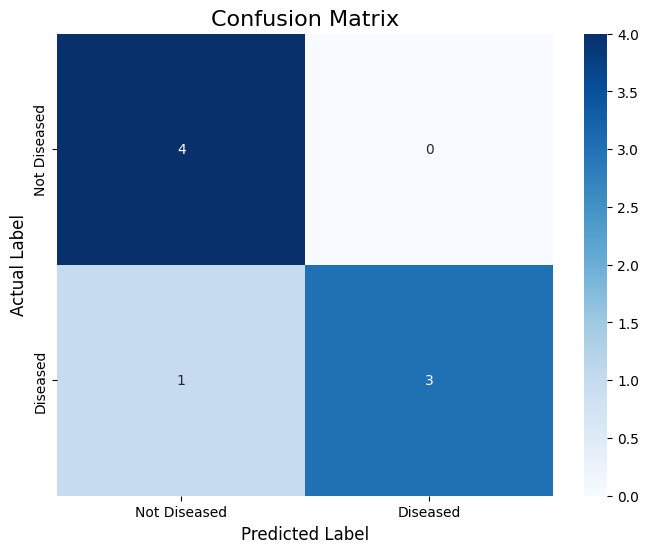

In [ ]:
# ============================================
# 27. CONFUSION MATRIX
# ============================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Not Diseased",
        "Diseased"
    ],
    yticklabels=[
        "Not Diseased",
        "Diseased"
    ]
)

plt.xlabel(
    "Predicted Label",
    fontsize=12
)

plt.ylabel(
    "Actual Label",
    fontsize=12
)

plt.title(
    "Confusion Matrix",
    fontsize=16
)

plt.show()


In [ ]:
# ============================================
# 28. CLASSIFICATION REPORT
# ============================================

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Not Diseased",
            "Diseased"
        ]
    )
)

              precision    recall  f1-score   support

Not Diseased       0.80      1.00      0.89         4
    Diseased       1.00      0.75      0.86         4

    accuracy                           0.88         8
   macro avg       0.90      0.88      0.87         8
weighted avg       0.90      0.88      0.87         8



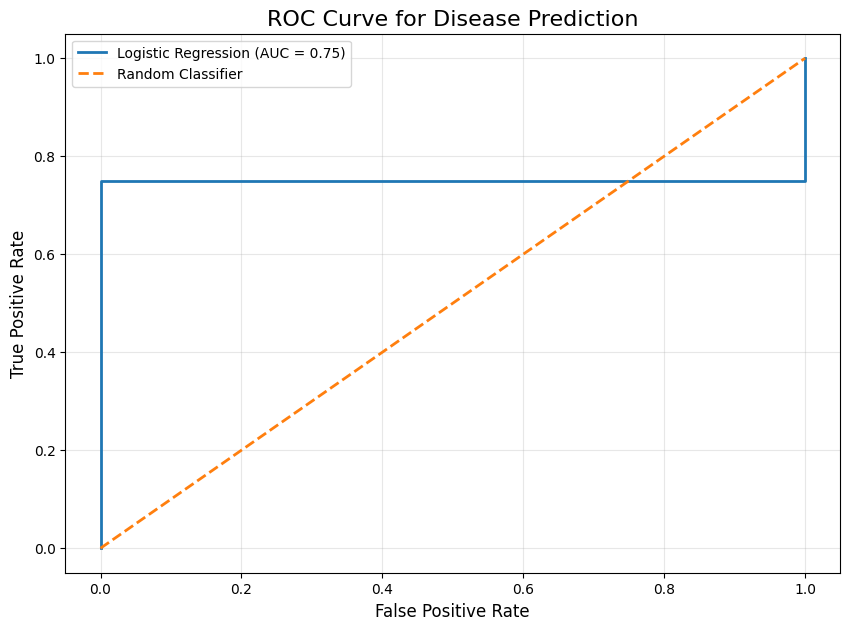

In [ ]:
# ============================================
# 29. ROC CURVE
# ============================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

auc_score = roc_auc_score(
    y_test,
    y_probability
)

plt.figure(figsize=(10, 7))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Logistic Regression (AUC = {auc_score:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12
)

plt.title(
    "ROC Curve for Disease Prediction",
    fontsize=16
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.show()

In [ ]:
# ============================================
# 30. CALCULATE AUC SCORE
# ============================================

print(
    "ROC-AUC Score:",
    round(auc_score, 4)
)

ROC-AUC Score: 0.75


In [ ]:
# ============================================
# 31. MODEL EVALUATION SUMMARY
# ============================================

print("============================================")
print("MODEL EVALUATION")
print("============================================")

print(
    "Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

print(
    "ROC-AUC Score:",
    round(auc_score, 4)
)

print("============================================")

MODEL EVALUATION
Accuracy: 87.5 %
ROC-AUC Score: 0.75


In [ ]:
# ============================================
# 32. PREDICT DISEASE FOR A NEW PERSON
# ============================================

new_person = pd.DataFrame({
    "Age": [40],
    "Gender": [1],
    "Smoker status": [1]
})

predicted_class = model.predict(
    new_person
)[0]

disease_probability = model.predict_proba(
    new_person
)[0][1]

print(
    "Disease Probability:",
    round(
        disease_probability * 100,
        2
    ),
    "%"
)

if predicted_class == 1:
    print(
        "Prediction: SUSCEPTIBLE TO DISEASE"
    )
else:
    print(
        "Prediction: NOT SUSCEPTIBLE TO DISEASE"
    )

Disease Probability: 72.14 %
Prediction: SUSCEPTIBLE TO DISEASE


In [ ]:
# ============================================
# 33. FINAL MODEL RESULTS
# ============================================

print("============================================")
print("FINAL MODEL RESULTS")
print("============================================")

print(
    "Model: Logistic Regression"
)

print(
    "Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

print(
    "ROC-AUC Score:",
    round(auc_score, 4)
)

print("============================================")


FINAL MODEL RESULTS
Model: Logistic Regression
Accuracy: 87.5 %
ROC-AUC Score: 0.75


# Conclusion

Logistic Regression model was developed successfully for finding out whether the individual is prone to the particular disease or not.

Disease was taken as the dependent variable, whereas Age, Gender, and Smoker were taken as the independent variables.

Categorical variables were converted to numeric values prior to training the model. Afterward, data was split into training and testing data.

The Logistic Regression model was trained to make predictions on both disease class as well as the probability of disease susceptibility.

Accuracy, confusion matrix, classification report, and ROC-AUC score were considered to measure the performance of the Logistic Regression model.

In addition, Logistic Regression can be used to calculate the probability of disease susceptibility of a new individual on the basis of their age, gender, and smoker status.

Therefore, Logistic Regression is an apt machine learning method for this particular classification problem.